# Setup and Context

<img src="https://i.imgur.com/gugIA5r.png" width=700>

### Introduction

Dr Ignaz Semmelweis was a Hungarian physician born in 1818 who worked in the Vienna General Hospital. In the past people thought of illness as caused by "bad air" or evil spirits. But in the 1800s Doctors started looking more at anatomy, doing autopsies and started making arguments based on data. Dr Semmelweis suspected that something was going wrong with the procedures at Vienna General Hospital. Semmelweis wanted to figure out why so many women in maternity wards were dying from childbed fever (i.e., [puerperal fever](https://en.wikipedia.org/wiki/Postpartum_infections)).

<img src=https://i.imgur.com/lSyNUwR.png width=700>

Today I will become Dr Semmelweis. This is my office 👆. I will step into Dr Semmelweis' shoes and analyse the same data collected from 1841 to 1849.

### The Data Source

Dr Semmelweis published his research in 1861. I found the scanned pages of the [full text with the original tables in German](http://www.deutschestextarchiv.de/book/show/semmelweis_kindbettfieber_1861), but an excellent [English translation can be found here](http://graphics8.nytimes.com/images/blogs/freakonomics/pdf/the%20etiology,%20concept%20and%20prophylaxis%20of%20childbed%20fever.pdf).

<img src=https://i.imgur.com/6HfLtaC.png width=500>

### Upgrade plotly (only Google Colab Notebook)

Google Colab may not be running the latest version of plotly. If you're working in Google Colab, uncomment the line below, run the cell, and restart your notebook server.

In [ ]:
# %pip install --upgrade plotly

### Import Statements

In [ ]:
import pandas as pd
import numpy as np
import plotly.express as px
import seaborn as sns
import matplotlib.pyplot as plt
import matplotlib.dates as mdates

### Notebook Presentation

In [ ]:
pd.options.display.float_format = '{:,.2f}'.format

# Create locators for ticks on the time axis


from pandas.plotting import register_matplotlib_converters
register_matplotlib_converters()

### Read the Data

In [ ]:
df_yearly = pd.read_csv('annual_deaths_by_clinic.csv')
# parse_dates avoids DateTime conversion later
df_monthly = pd.read_csv('monthly_deaths.csv',
                      parse_dates=['date'])

# Preliminary Data Exploration

* What is the shape of df_yearly and df_monthly? How many rows and columns?
* What are the column names?
* Which years are included in the dataset?
* Are there any NaN values or duplicates?
* What were the average number of births that took place per month?
* What were the average number of deaths that took place per month?

In [ ]:
# What is the shape of df_yearly and df_monthly? How many rows and columns?
print(f'Shape of yearly deaths: {df_yearly.shape}\nShape of montly deaths: {df_monthly.shape}')

# What are the column names?
print(f'Columns names of yearly deaths are: {df_yearly.columns}\nColumns names of monthly deaths are: {df_monthly.columns}')

# Which years are included in the dataset?
print(f'Years included in the dataset for annual deaths are: {df_yearly.year.drop_duplicates().values}')

# print(f"Years included in the dataset for monthly deaths are: {sorted(df_monthly.date.dt.year.unique())}")
print(f"Years included in the dataset for monthly deaths are: {df_monthly.date.dt.year.drop_duplicates().values}")

Shape of yearly deaths: (12, 4)
Shape of montly deaths: (98, 3)
Columns names of yearly deaths are: Index(['year', 'births', 'deaths', 'clinic'], dtype='object')
Columns names of monthly deaths are: Index(['date', 'births', 'deaths'], dtype='object')
Years included in the dataset for annual deaths are: [1841 1842 1843 1844 1845 1846]
Years included in the dataset for monthly deaths are: [1841 1842 1843 1844 1845 1846 1847 1848 1849]


In [ ]:
# Are there any NaN values or duplicates?
df_yearly.isna()

,year,births,deaths,clinic
0,False,False,False,False
1,False,False,False,False
2,False,False,False,False
3,False,False,False,False
4,False,False,False,False
5,False,False,False,False
6,False,False,False,False
7,False,False,False,False
8,False,False,False,False
9,False,False,False,False


In [ ]:
# What were the average number of births that took place per month?
print(f'Average number of births that took place per month is: {df_monthly.births.mean():.0f}')
df_monthly.births.describe()

# What were the average number of deaths that took place per month?
print(f'Average number of deaths that took place per month is: {df_monthly.deaths.mean():.0f}')
df_monthly.deaths.describe()

Average number of births that took place per month is: 267
Average number of deaths that took place per month is: 22


,deaths
count,98.00
mean,22.47
std,18.14
min,0.00
25%,8.00
50%,16.50
75%,36.75
max,75.00


### Check for Nan Values and Duplicates

In [ ]:
# Another way:
df_yearly.info()
# For duplicates:

print(f'\nAny yearly duplicates? {df_yearly.duplicated().values.any()}')
print(f'Any monthly duplicates? {df_monthly.duplicated().values.any()}')

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 12 entries, 0 to 11
Data columns (total 4 columns):
 #   Column  Non-Null Count  Dtype 
---  ------  --------------  ----- 
 0   year    12 non-null     int64 
 1   births  12 non-null     int64 
 2   deaths  12 non-null     int64 
 3   clinic  12 non-null     object
dtypes: int64(3), object(1)
memory usage: 516.0+ bytes

Any yearly duplicates? False
Any monthly duplicates? False


### Descriptive Statistics

In [ ]:
df_monthly.births.describe()

,births
count,98.00
mean,267.00
std,41.77
min,190.00
25%,242.50
50%,264.00
75%,292.75
max,406.00


### Percentage of Women Dying in Childbirth

How dangerous was childbirth in the 1840s in Vienna?

* Using the annual data, calculate the percentage of women giving birth who died throughout the 1840s at the hospital.


In comparison, the United States recorded 18.5 maternal deaths per 100,000 or 0.018% in 2013 [(source).](
https://en.wikipedia.org/wiki/Maternal_death#:~:text=The%20US%20has%20the%20%22highest,17.8%20per%20100%2C000%20in%202009)

In [ ]:
prob = df_yearly.deaths.sum() / df_yearly.births.sum() * 100
print(f'Chances of dying in the 1840s in Vienna: {prob:.2f}%')


Chances of dying in the 1840s in Vienna: 7.08%


# Visualise the Total Number of Births 🤱 and Deaths 💀 over Time

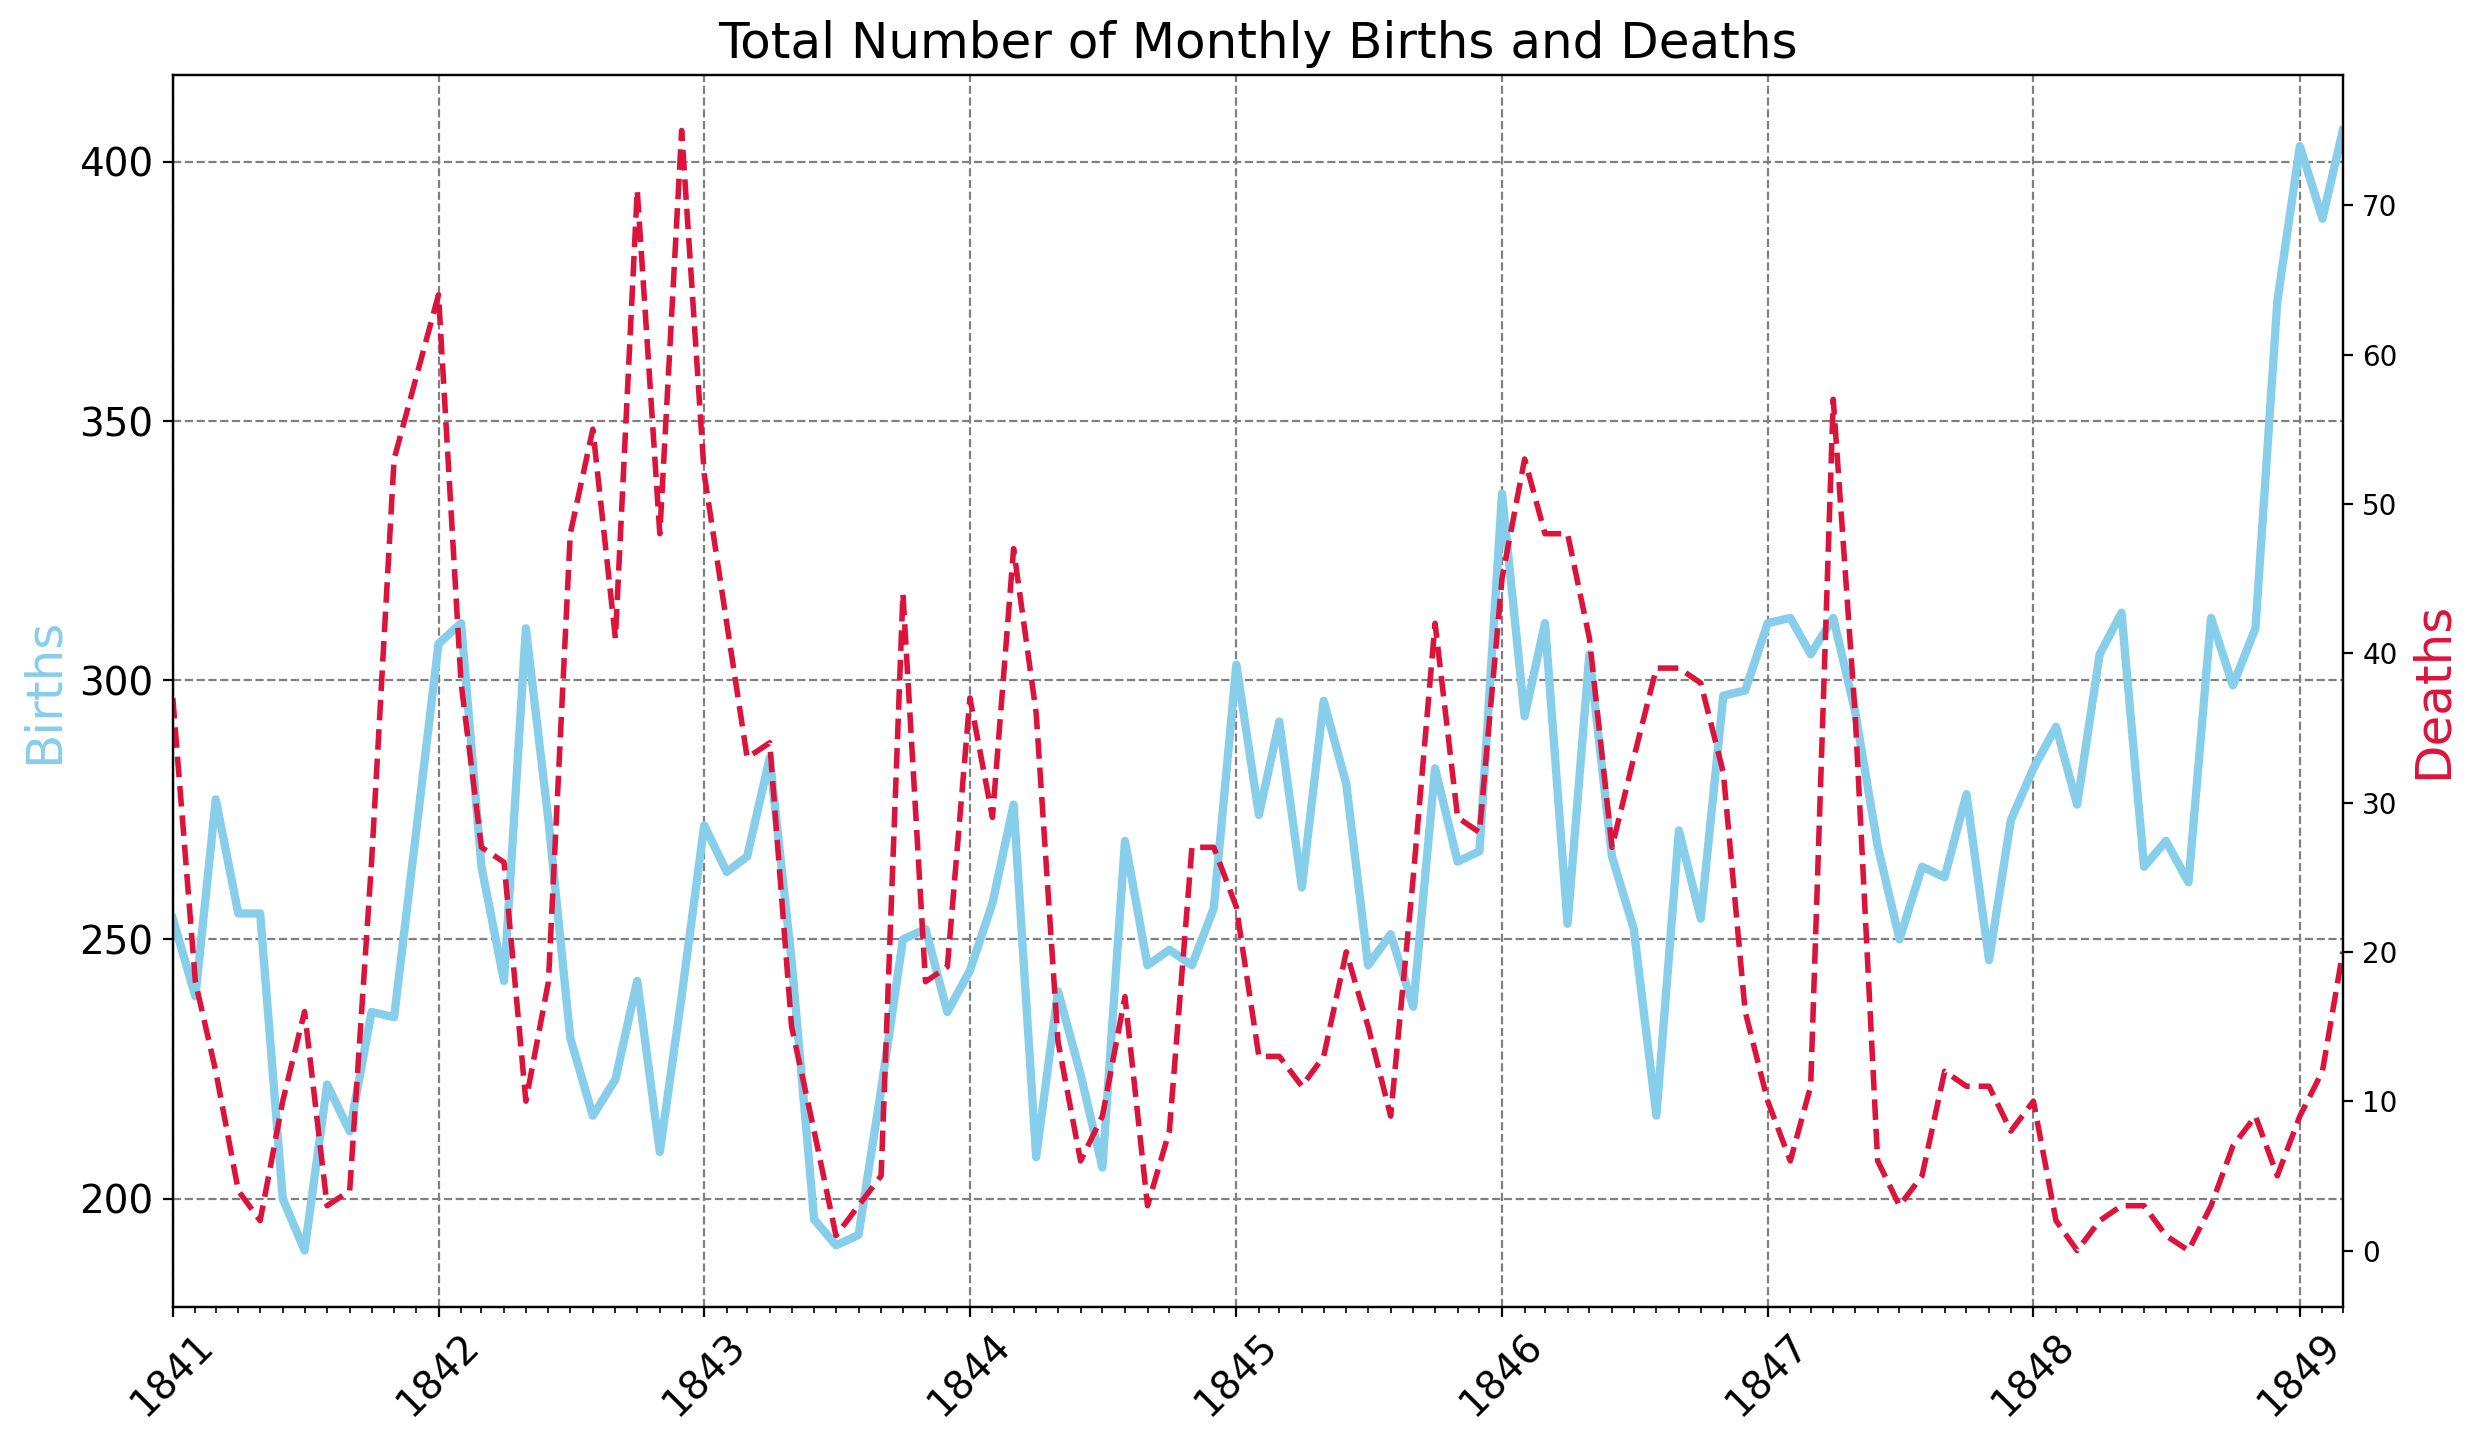

In [ ]:
# Create locators for ticks on the time axis
years = mdates.YearLocator()
months = mdates.MonthLocator()
years_fmt = mdates.DateFormatter('%Y')

plt.figure(figsize=(14,8), dpi=200)
plt.title('Total Number of Monthly Births and Deaths', fontsize=18)
plt.yticks(fontsize=14)
plt.xticks(fontsize=14, rotation=45)

ax1 = plt.gca()
ax2 = ax1.twinx()

ax1.set_ylabel('Births', color='skyblue', fontsize=18)
ax2.set_ylabel('Deaths', color='crimson', fontsize=18)

# Use Locators
ax1.set_xlim([df_monthly.date.min(), df_monthly.date.max()])
ax1.xaxis.set_major_locator(years)
ax1.xaxis.set_major_formatter(years_fmt)
ax1.xaxis.set_minor_locator(months)

ax1.grid(color='grey', linestyle='--')

ax1.plot(df_monthly.date,
         df_monthly.births,
         color='skyblue',
         linewidth=3)

ax2.plot(df_monthly.date,
         df_monthly.deaths,
         color='crimson',
         linewidth=2,
         linestyle='--')

plt.show()


In [ ]:
df_monthly

,date,births,deaths
0,1841-01-01,254,37
1,1841-02-01,239,18
2,1841-03-01,277,12
3,1841-04-01,255,4
4,1841-05-01,255,2
...,...,...,...
93,1848-11-01,310,9
94,1848-12-01,373,5
95,1849-01-01,403,9
96,1849-02-01,389,12


# The Yearly Data Split by Clinic

Now let's look at the annual data instead.

* Which clinic is bigger or more busy judging by the number of births?
* Has the hospital had more patients over time?
* What was the highest number of deaths recorded in clinic 1 and clinic 2?

In [ ]:
clinic_1 = df_yearly.query("clinic == 'clinic 1'")
clinic_2 = df_yearly.query("clinic == 'clinic 2'")
clinic_2

px.line(clinic_1, x='year', y=['births', 'deaths'], title='Birth and Death rates in Clinic 1')


In [ ]:
px.line(clinic_2, x='year', y=['births', 'deaths'], title='Birth and Death rates in Clinic 2')

In [ ]:
# Which clinic is bigger or more busy judging by the number of births?
print('Clinic 1')
# Has the hospital had more patients over time?
print('Yes.')
# What was the highest number of deaths recorded in clinic 1 and clinic 2?
print(f'The highest number of deaths recorded in Clinic 1 is {clinic_1.deaths.max()} and in Clinic 2 is {clinic_2.deaths.max()}')

Clinic 1
Yes.
The highest number of deaths recorded in Clinic 1 is 518 and in Clinic 2 is 202


In [ ]:
line = px.line(df_yearly,
               x='year',
               y='births',
               color='clinic',
               title='Total Yearly Births by Clinic')

line.show()

In [ ]:
line = px.line(df_yearly,
               x='year',
               y='deaths',
               color='clinic',
               title='Total Yearly Deaths by Clinic')

line.show()

### Calculate the Proportion of Deaths at Each Clinic

**Challenge**: Calculate the proportion of maternal deaths per clinic. That way we can compare like with like.
* Which clinic has a higher proportion of deaths?
* What is the highest monthly death rate in clinic 1 compared to clinic 2?

In [ ]:
df_yearly['pct_deaths'] = df_yearly.deaths / df_yearly.births * 100

clinic_1 = df_yearly[df_yearly.clinic == 'clinic 1']
avg_c1 = clinic_1.deaths.sum() / clinic_1.births.sum() * 100
avg_c1
print(f'Average death rate in clinic 1 is {avg_c1:.3}%.')

Average death rate in clinic 1 is 9.92%.


In [ ]:
clinic_2 = df_yearly[df_yearly.clinic == 'clinic 2']
avg_c2 = clinic_2.deaths.sum() / clinic_2.births.sum() * 100
print(f'Average death rate in clinic 2 is {avg_c2:.3}%.')
clinic_2


Average death rate in clinic 2 is 3.88%.


,year,births,deaths,clinic,pct_deaths
6,1841,2442,86,clinic 2,3.52
7,1842,2659,202,clinic 2,7.60
8,1843,2739,164,clinic 2,5.99
9,1844,2956,68,clinic 2,2.30
10,1845,3241,66,clinic 2,2.04
11,1846,3754,105,clinic 2,2.80


### Plotting the Proportion of Yearly Deaths by Clinic

In [ ]:
line_2 = px.line(df_yearly,
               x='year',
               y='pct_deaths',
               color='clinic',
               title='Proportion of Yearly Deaths by Clinic')

line_2.show()

In [ ]:
# Which clinic has a higher proportion of deaths?
print('The first one.')

# What is the highest yearly death rate in clinic 1 compared to clinic 2?
df_yearly.groupby('clinic')['pct_deaths'].max()


The first one.


,pct_deaths
clinic,
clinic 1,15.76
clinic 2,7.60


# The Effect of Handwashing

Dr Semmelweis made handwashing obligatory in the summer of 1947. In fact, he ordered people to wash their hands with clorine (instead of water).

In [ ]:
# Date when handwashing was made mandatory
handwashing_start = pd.to_datetime('1847-06-01')

In [ ]:
df_monthly['death_rate'] = df_monthly.deaths / df_monthly.births

before_washing = df_monthly[df_monthly.date < handwashing_start].set_index('date')

after_washing = df_monthly[df_monthly.date >= handwashing_start ]
after_washing


,date,births,deaths,death_rate
76,1847-06-01,268,6,0.02
77,1847-07-01,250,3,0.01
78,1847-08-01,264,5,0.02
79,1847-09-01,262,12,0.05
80,1847-10-01,278,11,0.04
81,1847-11-01,246,11,0.04
82,1847-12-01,273,8,0.03
83,1848-01-01,283,10,0.04
84,1848-02-01,291,2,0.01
85,1848-03-01,276,0,0.00


In [ ]:
# Calculate the average death rate prior to June 1947.
avg_death_rate_before = before_washing.deaths.sum() / before_washing.births.sum() * 100

# Calculate the average death rate after June 1947.
avg_death_rate_after = after_washing.deaths.sum() / after_washing.births.sum() * 100

print(f'Average death rate before washing hands was {avg_death_rate_before:.3}%.')
print(f'Average death rate after washing hands was {avg_death_rate_after:.3}%.')

Average death rate before washing hands was 10.5%.
Average death rate after washing hands was 2.15%.


### Calculate a Rolling Average of the Death Rate

In [ ]:
before_washing['rolling_avg'] = before_washing['death_rate'].rolling(window=6).mean()

# before_washing = before_washing.drop(['pct_deaths', 'Rolling_Avg_'], axis=1)

before_washing


,births,deaths,death_rate,rolling_avg
date,,,,
1841-01-01,254,37,0.15,NaN
1841-02-01,239,18,0.08,NaN
1841-03-01,277,12,0.04,NaN
1841-04-01,255,4,0.02,NaN
1841-05-01,255,2,0.01,NaN
...,...,...,...,...
1847-01-01,311,10,0.03,0.11
1847-02-01,312,6,0.02,0.08
1847-03-01,305,11,0.04,0.07


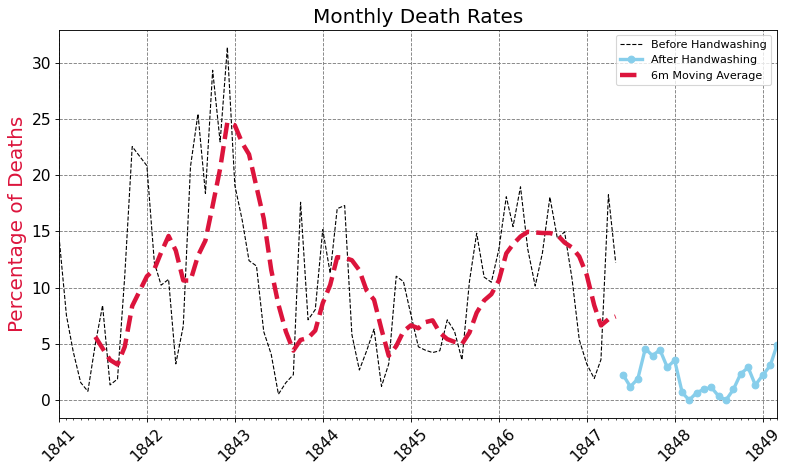

In [ ]:

# Create locators and formatters
years = mdates.YearLocator()
months = mdates.MonthLocator()
years_fmt = mdates.DateFormatter('%Y')

fig, ax = plt.subplots(figsize=(10, 6), dpi=80)

ax.set_title('Monthly Death Rates', fontsize=18)
ax.set_ylabel('Percentage of Deaths', color='crimson', fontsize=18)
ax.tick_params(axis='x', labelsize=14, rotation=45)
ax.tick_params(axis='y', labelsize=14)

ax.set_xlim([before_washing.index.min(), after_washing.date.max()])
ax.xaxis.set_major_locator(years)
ax.xaxis.set_major_formatter(years_fmt)
ax.xaxis.set_minor_locator(months)

ax.grid(color='grey', linestyle='--')

ax.plot(before_washing.index,
        before_washing.death_rate * 100,
        color='black',
        linestyle='--',
        linewidth=1,
        label='Before Handwashing')

ax.plot(after_washing.date,
        after_washing.death_rate * 100,
        color='skyblue',
        linewidth=3,
        marker='o',
        label='After Handwashing')

ax.plot(before_washing.index,
        before_washing.rolling_avg * 100,
        color='crimson',
        linewidth=4,
        linestyle='--',
        label='6m Moving Average')

# Add legend
ax.legend()

# Adjust layout
fig.tight_layout()
plt.show()


### Statistics - Calculate the Difference in the Average Monthly Death Rate

* What was the average percentage of monthly deaths before handwashing?
* What was the average percentage of monthly deaths after handwashing was made obligatory?
* By how much did handwashing reduce the average chance of dying in childbirth in percentage terms?
* How do these numbers compare to the average for all the 1840s that we calculated earlier?
* How many times lower are the chances of dying after handwashing compared to before?

In [ ]:
# What was the average percentage of monthly deaths before handwashing?
print(f'Avg perc.of monthly deaths before handashing: {before_washing.death_rate.mean() * 100:.2f}%')

# What was the average percentage of monthly deaths after handwashing was made obligatory?
print(f'Avg perc.of monthly deaths after handashing: {after_washing.death_rate.mean() * 100:.2f}%')

# By how much did handwashing reduce the average chance of dying in childbirth in percentage terms?
print(f'Handwashing reduced the average chance of dying in childbirth by')
print(f'{(before_washing.death_rate.mean() - after_washing.death_rate.mean())*100:.2f}%')



Avg perc.of monthly deaths before handashing: 10.50%
Avg perc.of monthly deaths after handashing: 2.11%
Handwashing reduced the average chance of dying in childbirth by
8.40%


In [ ]:
before = before_washing.death_rate.mean()
after = after_washing.death_rate.mean()

times_lower = int(round(before / after))
# How many times lower are the chances of dying after handwashing compared to before?
print(f'Death rate was {times_lower} times lower after handwashing.')


Death rate was 5 times lower after handwashing.


### Box Plots to Show How the Death Rate Changed Before and After Handwashing





In [ ]:
df_monthly['bef_or_aft_wash'] = np.where(df_monthly.date < handwashing_start, 'before', 'after')
df_monthly

,date,births,deaths,death_rate,bef_or_aft_wash
0,1841-01-01,254,37,0.15,before
1,1841-02-01,239,18,0.08,before
2,1841-03-01,277,12,0.04,before
3,1841-04-01,255,4,0.02,before
4,1841-05-01,255,2,0.01,before
...,...,...,...,...,...
93,1848-11-01,310,9,0.03,after
94,1848-12-01,373,5,0.01,after
95,1849-01-01,403,9,0.02,after
96,1849-02-01,389,12,0.03,after


In [ ]:
fig_1 = px.box(
    df_monthly,
    x="bef_or_aft_wash",
    y="death_rate",
    color="bef_or_aft_wash",
    notched=True,
    title="Comparison of Death Rates Before and After Handwashing"
)

fig_1.update_layout(
    yaxis_tickformat=".0%"
)

fig_1.show()

In [ ]:
df_monthly

,date,births,deaths,death_rate,bef_or_aft_wash
0,1841-01-01,254,37,0.15,before
1,1841-02-01,239,18,0.08,before
2,1841-03-01,277,12,0.04,before
3,1841-04-01,255,4,0.02,before
4,1841-05-01,255,2,0.01,before
...,...,...,...,...,...
93,1848-11-01,310,9,0.03,after
94,1848-12-01,373,5,0.01,after
95,1849-01-01,403,9,0.02,after
96,1849-02-01,389,12,0.03,after


### Histograms to Visualise the Monthly Distribution of Outcomes



In [ ]:
fig = px.histogram(
    df_monthly,
    x='death_rate',
    color='bef_or_aft_wash',
    histnorm='percent',
    nbins=30,
    opacity=0.6,
    marginal = 'box'
)

fig.update_layout(
    title="Monthly Percentage of Deaths Before and After Handwashing",
    xaxis_title="Death Rate (%)",
    yaxis_title="Percent of Months",
)

fig.update_layout(xaxis_tickformat=".0%")
fig.show()


###  Kernel Density Estimate (KDE) to visualise a smooth distribution



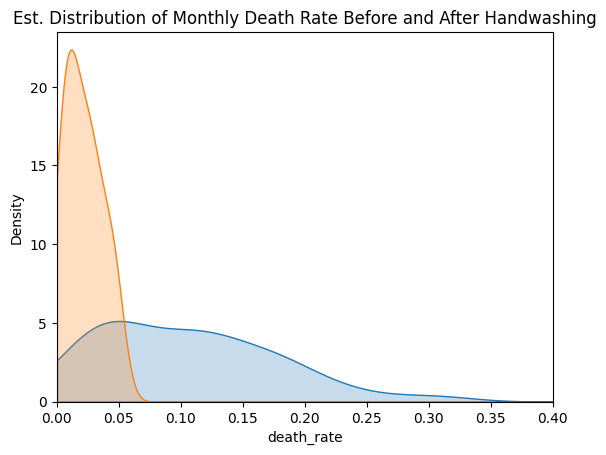

In [ ]:
sns.kdeplot(before_washing.death_rate,
            fill=True,
            clip=(0,1))
sns.kdeplot(after_washing.death_rate,
            fill=True,
            clip=(0,1))
plt.title('Est. Distribution of Monthly Death Rate Before and After Handwashing')
plt.xlim(0, 0.40)
plt.show()

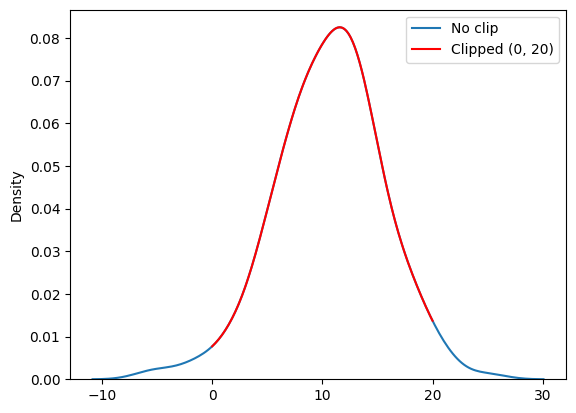

### T-Test to Show Statistical Significance

If the p-value is less than 1% then we can be 99% certain that handwashing has made a difference to the average monthly death rate.

* Is the difference in the average proportion of monthly deaths statistically significant at the 99% level?



In [ ]:
from scipy import stats

t_stat, p_value = stats.ttest_ind(
    before_washing["death_rate"],
    after_washing["death_rate"],
    equal_var=False
)

t_stat, p_value

# Is the difference in the average proportion of monthly deaths statistically significant at the 99% level?
print("Yes. 1.4e-15 is 0.0000000000000014 and it's less than 1% so it's statistically significant.")



Yes. 1.4e-15 is 0.0000000000000014 and it's less than 1% so it's statistically significant.
